In [1]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.12.1+cpu
False


In [2]:
import sys
print(sys.executable)

C:\Users\korisnik\AppData\Local\Programs\Python\Python312\python.exe


In [4]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install scikit-image

Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.ndimage import label
from skimage.measure import euler_number
from IPython.display import HTML
from PIL import Image
import librosa

def threshold_image(image, threshold):
    return (image >= threshold).astype(np.uint8)

def animate_filtration(image, num_frames=30, size=None, cmap="gray", interval=600):
    """
    image: 2D NumPy array
    returns: HTML animation for Jupyter/Colab
    """

    image = np.asarray(image)

    # If RGB image, convert to grayscale
    if image.ndim == 3:
        image = image.mean(axis=2)

    # Optional resize
    if size is not None:
        img = Image.fromarray(image.astype(np.uint8))
        img = img.resize(size)
        image = np.array(img)

    thresholds = np.linspace(image.max(), image.min(), num_frames)

    fig, ax = plt.subplots()

    im = ax.imshow(
        np.zeros_like(image),
        cmap=cmap,
        vmin=0,
        vmax=1
    )

    title = ax.set_title("")
    ax.set_xticks([])
    ax.set_yticks([])

    def update(frame):
        t = thresholds[frame]
        binary = threshold_image(image, t)

        _, beta_0 = label(binary)
        chi = euler_number(binary, connectivity=1)
        beta_1 = beta_0 - chi

        im.set_data(binary)
        title.set_text(
            f"Threshold t = {t:.2f}\n"
            f"β₀ components = {beta_0}, β₁ holes = {beta_1}"
        )

        return [im, title]

    ani = FuncAnimation(
        fig,
        update,
        frames=len(thresholds),
        interval=interval,
        blit=False,
        repeat=True
    )

    plt.close(fig)

    return HTML(ani.to_jshtml())

In [7]:
%pip install librosa

Note: you may need to restart the kernel to use updated packages.


In [8]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\korisnik\Downloads\topologija_muzika-main\topologija_muzika-main
['.gitattributes', '.ipynb_checkpoints', 'data', 'guitar.mp3', 'main-Copy1.ipynb', 'main.ipynb', 'README.md']


In [9]:
import librosa

y, sr = librosa.load("guitar.mp3", sr=22050)
print(y.shape, sr)

C:\Users\korisnik\AppData\Local\Temp\ipykernel_3620\4001924196.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load("guitar.mp3", sr=22050)
C:\Users\korisnik\AppData\Local\Programs\Python\Python312\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


NoBackendError: 

In [ ]:
import os

print(os.getcwd())
print(os.path.exists("guitar.mp3"))
print(os.path.isfile("guitar.mp3"))
print(os.path.getsize("guitar.mp3"))

In [10]:
import librosa
import numpy as np
import matplotlib.pyplot as plt



def compute_log_mel_spectrogram(
    audio_path,
    sr=22050,
    n_fft=2048,
    hop_length=512,
    n_mels=128
):
    y, sr = librosa.load(audio_path, sr=sr, mono=True)

    S = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        power=2.0
    )

    return librosa.power_to_db(S, ref=np.max)

def plot_log_mel_spectrogram(log_S):
    plt.imshow(log_S, origin="lower", aspect="auto", cmap="magma")
    plt.colorbar(label="dB")
    plt.xlabel("Time frame")
    plt.ylabel("Mel frequency bin")
    plt.title("Log-mel spectrogram")
    plt.show()

log_S = compute_log_mel_spectrogram("guitar.mp3")
print(log_S.shape)  # (frequency_bins, time_frames)
plot_log_mel_spectrogram(log_S)

C:\Users\korisnik\AppData\Local\Temp\ipykernel_3620\3682958928.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=sr, mono=True)


NoBackendError: 

In [12]:
animate_filtration(log_S, num_frames=30)

NameError: name 'log_S' is not defined

In [11]:
%pip install gudhi

Note: you may need to restart the kernel to use updated packages.


In [12]:
import gudhi
from gudhi.representations import Landscape
import numpy as np

def compute_persistence(image):
    cubical_complex = gudhi.CubicalComplex(top_dimensional_cells=image)
    cubical_complex.compute_persistence()
    
    h0_diagram = cubical_complex.persistence_intervals_in_dimension(0)
    h1_diagram = cubical_complex.persistence_intervals_in_dimension(1)
    
    
    # Removing infinite deaths, landscapes need finite intervals
    h0_finite = h0_diagram[np.isfinite(h0_diagram[:, 1])]
    h1_finite = h1_diagram[np.isfinite(h1_diagram[:, 1])]
    
    # num_landscapes = number of landscape layers λ1, λ2, ...
    # resolution = number of sample points on the x-axis
    landscape = Landscape(num_landscapes=5, resolution=100)
    
    h0_landscape = landscape.fit_transform([h0_finite])
    h1_landscape = landscape.fit_transform([h1_finite])
    
    return h0_diagram, h1_diagram, h0_landscape, h1_landscape

grid_data = np.random.randint(1, 15, size=(7, 7))
print("Random 7x7 Matrix:")
print(grid_data)

h0_diagram, h1_diagram, h0_landscape, h1_landscape = compute_persistence(grid_data)

print(h0_diagram)
print(h1_diagram)

print("H0 landscape shape:", h0_landscape.shape)
print("H1 landscape shape:", h1_landscape.shape)
#print("H0 landscape vector:\n", h0_landscape)

Random 7x7 Matrix:
[[ 5  6  8  1  5  3 12]
 [ 7 14  4  1  6  4  5]
 [11  1  3  4 13  3 11]
 [ 6  4 14 11  6  9  3]
 [ 5  2 14  8  8 10  1]
 [ 9  2  3 14  5 10  5]
 [13  4 14  3  5  1  1]]
[[ 1.  3.]
 [ 2.  4.]
 [ 3.  4.]
 [ 1.  5.]
 [ 1.  5.]
 [ 5.  6.]
 [ 1. inf]]
[[ 8. 10.]
 [ 6. 13.]
 [ 7. 14.]
 [ 8. 14.]
 [ 5. 14.]]
H0 landscape shape: (1, 500)
H1 landscape shape: (1, 500)


In [13]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


Pišemo CNN gde možemo da isključimo sloj perzistencije da bi uočili njihov doprinos neuronskoj mreži

In [60]:
import torch
import torch.nn as nn

num_classes = 2

class AudioClassifier(nn.Module):

    def __init__(self, use_topology=False, topo_dim=1000):
        super().__init__()

        self.use_topology = use_topology

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten()
        )

        self.cnn_summary = nn.Linear(32 * 4 * 4, 128)

        if use_topology:
            self.topo_summary = nn.Sequential(
                nn.Linear(topo_dim, 256),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(256, 128),
                nn.ReLU()
            )

            self.classifier = nn.Sequential(
                nn.Linear(256, 128),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(128, num_classes)
            )

        else:
            self.classifier = nn.Sequential(
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Linear(64, num_classes)
            )

    def forward(self, spectrogram, landscape=None):
        cnn_features = self.cnn(spectrogram)
        cnn_features = self.cnn_summary(cnn_features)

        if self.use_topology:
            topo_features = self.topo_summary(landscape)
            x = torch.cat([cnn_features, topo_features], dim=1)
        else:
            x = cnn_features

        return self.classifier(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_cnn = AudioClassifier(use_topology=False).to(device)
model_cnn_topo = AudioClassifier(use_topology=True).to(device)

print("Models created.")

Models created.


In [15]:
from pathlib import Path
import librosa
import numpy as np
import pandas as pd

def create_music_dataset(genres = ["pop", "rock"]):
    records = []

    for label, genre in enumerate(genres):

        genre_path = Path("data/genres") / genre

        for file_path in genre_path.glob("*.wav"):

            spectrogram = compute_log_mel_spectrogram(file_path)

            records.append({
                "file": str(file_path),
                "genre": genre,
                "label": label,
                "spectrogram": spectrogram
            })

    return pd.DataFrame(records)

df = create_music_dataset(["pop", "rock"])
df.head()

,file,genre,label,spectrogram
0,data\genres\pop\pop.00000.wav,pop,0,"[[-10.855934, -7.7729454, -7.574999, -8.024984..."
1,data\genres\pop\pop.00001.wav,pop,0,"[[-13.610338, -10.763615, -9.43648, -11.210834..."
2,data\genres\pop\pop.00002.wav,pop,0,"[[-20.55059, -17.711145, -17.620384, -17.01046..."
3,data\genres\pop\pop.00003.wav,pop,0,"[[-57.03638, -48.159576, -39.160786, -35.00329..."
4,data\genres\pop\pop.00004.wav,pop,0,"[[-17.353067, -14.092247, -14.026318, -14.4201..."


In [17]:
print(df.shape)
print(df.columns)
print(df.head())

(200, 4)
Index(['file', 'genre', 'label', 'spectrogram'], dtype='str')
                            file genre  label  \
0  data\genres\pop\pop.00000.wav   pop      0   
1  data\genres\pop\pop.00001.wav   pop      0   
2  data\genres\pop\pop.00002.wav   pop      0   
3  data\genres\pop\pop.00003.wav   pop      0   
4  data\genres\pop\pop.00004.wav   pop      0   

                                         spectrogram  
0  [[-10.855934, -7.7729454, -7.574999, -8.024984...  
1  [[-13.610338, -10.763615, -9.43648, -11.210834...  
2  [[-20.55059, -17.711145, -17.620384, -17.01046...  
3  [[-57.03638, -48.159576, -39.160786, -35.00329...  
4  [[-17.353067, -14.092247, -14.026318, -14.4201...  


In [18]:
print(type(df["spectrogram"].iloc[0]))
print(df["spectrogram"].iloc[0].shape)

print(df["spectrogram"].iloc[1].shape)
print(df["spectrogram"].iloc[2].shape)

<class 'numpy.ndarray'>
(128, 1293)
(128, 1293)
(128, 1293)


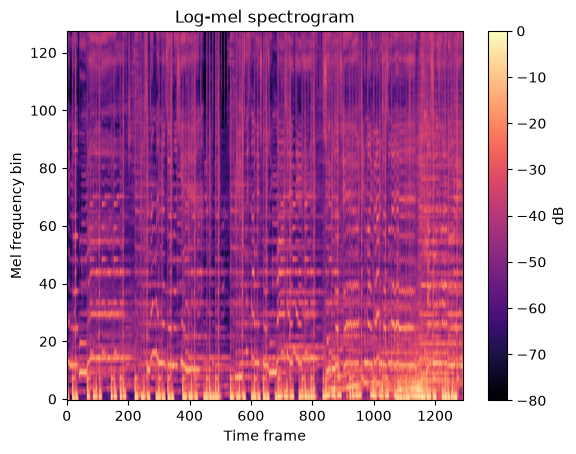

In [19]:
plot_log_mel_spectrogram(df.iloc[0]["spectrogram"])

In [20]:
def compute_landscapes(spectrogram):
    _, _, h0_landscape, h1_landscape = compute_persistence(spectrogram)
    return np.concatenate([
        h0_landscape.ravel(),
        h1_landscape.ravel()
    ])

df["landscape"] = df["spectrogram"].apply(compute_landscapes)
df.head()

,file,genre,label,spectrogram,landscape
0,data\genres\pop\pop.00000.wav,pop,0,"[[-10.855934, -7.7729454, -7.574999, -8.024984...","[1.0201813836977898, 2.0403627673955795, 3.060..."
1,data\genres\pop\pop.00001.wav,pop,0,"[[-13.610338, -10.763615, -9.43648, -11.210834...","[1.0204814892893668, 2.0409629785787335, 3.061..."
2,data\genres\pop\pop.00002.wav,pop,0,"[[-20.55059, -17.711145, -17.620384, -17.01046...","[0.9764181259295324, 1.9528362518590647, 2.929..."
3,data\genres\pop\pop.00003.wav,pop,0,"[[-57.03638, -48.159576, -39.160786, -35.00329...","[0.9468413671738353, 1.8936827343476705, 2.840..."
4,data\genres\pop\pop.00004.wav,pop,0,"[[-17.353067, -14.092247, -14.026318, -14.4201...","[0.8648988133179216, 1.7297976266358632, 2.594..."


In [21]:
df["landscape"].iloc[0].shape

(1000,)

In [22]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [23]:
def fix_spectrogram_shape(S, target_frames=130):
    # S je oblika (128, broj_vremenskih_frejmova)
    if S.shape[1] > target_frames:
        return S[:, :target_frames]
    elif S.shape[1] < target_frames:
        pad_width = target_frames - S.shape[1]
        return np.pad(S, ((0, 0), (0, pad_width)), mode="constant")
    else:
        return S

df["spectrogram_fixed"] = df["spectrogram"].apply(fix_spectrogram_shape)

print(df["spectrogram_fixed"].iloc[0].shape)

(128, 130)


In [24]:
from sklearn.model_selection import train_test_split

X = df[["spectrogram_fixed"]]
y = df[["label"]]

print(X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print(X_train.shape)

(200, 1)
(140, 1)


In [50]:
model_cnn = AudioClassifier(use_topology=False).to(device)
print("CNN model reset.")

CNN model reset.


In [51]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(
    np.stack(X_train["spectrogram_fixed"].values),
    dtype=torch.float32
).unsqueeze(1)

y_train_tensor = torch.tensor(
    y_train["label"].values,
    dtype=torch.long
)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([140, 1, 128, 130])
torch.Size([140])


In [52]:
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=16,
    shuffle=True
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=0.0005)
epochs = 75

for epoch in range(epochs):
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_cnn(inputs)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss / len(train_loader):.4f}")

Epoch 1/75, Loss: 0.8187
Epoch 2/75, Loss: 0.7921
Epoch 3/75, Loss: 0.7154
Epoch 4/75, Loss: 0.6545
Epoch 5/75, Loss: 0.6508
Epoch 6/75, Loss: 0.5974
Epoch 7/75, Loss: 0.5662
Epoch 8/75, Loss: 0.5201
Epoch 9/75, Loss: 0.5060
Epoch 10/75, Loss: 0.5074
Epoch 11/75, Loss: 0.4295
Epoch 12/75, Loss: 0.4150
Epoch 13/75, Loss: 0.4763
Epoch 14/75, Loss: 0.3920
Epoch 15/75, Loss: 0.4704
Epoch 16/75, Loss: 0.4775
Epoch 17/75, Loss: 0.4065
Epoch 18/75, Loss: 0.3953
Epoch 19/75, Loss: 0.3909
Epoch 20/75, Loss: 0.3675
Epoch 21/75, Loss: 0.4854
Epoch 22/75, Loss: 0.4018
Epoch 23/75, Loss: 0.4128
Epoch 24/75, Loss: 0.4243
Epoch 25/75, Loss: 0.3672
Epoch 26/75, Loss: 0.3828
Epoch 27/75, Loss: 0.3831
Epoch 28/75, Loss: 0.3658
Epoch 29/75, Loss: 0.3259
Epoch 30/75, Loss: 0.3293
Epoch 31/75, Loss: 0.2955
Epoch 32/75, Loss: 0.2773
Epoch 33/75, Loss: 0.2631
Epoch 34/75, Loss: 0.2445
Epoch 35/75, Loss: 0.2534
Epoch 36/75, Loss: 0.2453
Epoch 37/75, Loss: 0.2502
Epoch 38/75, Loss: 0.2954
Epoch 39/75, Loss: 0.

In [53]:
X_test_tensor = torch.tensor(
    np.stack(X_test["spectrogram_fixed"].values),
    dtype=torch.float32
).unsqueeze(1)

y_test_tensor = torch.tensor(
    y_test["label"].values,
    dtype=torch.long
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=16,
    shuffle=False
)

print(X_test_tensor.shape)
print(y_test_tensor.shape)

torch.Size([60, 1, 128, 130])
torch.Size([60])


In [54]:
model_cnn.eval()

correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model_cnn(inputs)
        predicted = torch.argmax(outputs, dim=1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

cnn_accuracy = correct / total

print(f"CNN accuracy: {cnn_accuracy:.4f}")

CNN accuracy: 0.9667


In [55]:
X_topo = df[["spectrogram_fixed", "landscape"]]
y_topo = df[["label"]]

X_topo_train, X_topo_test, y_topo_train, y_topo_test = train_test_split(
    X_topo,
    y_topo,
    test_size=0.3,
    random_state=42
)

X_train_spectro_tensor = torch.tensor(
    np.stack(X_topo_train["spectrogram_fixed"].values),
    dtype=torch.float32
).unsqueeze(1)

landscape_train_np = np.stack(X_topo_train["landscape"].values)
landscape_test_np = np.stack(X_topo_test["landscape"].values)

landscape_mean = landscape_train_np.mean(axis=0)
landscape_std = landscape_train_np.std(axis=0) + 1e-8

landscape_train_np = (landscape_train_np - landscape_mean) / landscape_std
landscape_test_np = (landscape_test_np - landscape_mean) / landscape_std

X_train_landscape_tensor = torch.tensor(
    landscape_train_np,
    dtype=torch.float32
)

y_train_topo_tensor = torch.tensor(
    y_topo_train["label"].values,
    dtype=torch.long
)

print(X_train_spectro_tensor.shape)
print(X_train_landscape_tensor.shape)
print(y_train_topo_tensor.shape)

torch.Size([140, 1, 128, 130])
torch.Size([140, 1000])
torch.Size([140])


In [63]:
model_cnn_topo = AudioClassifier(use_topology=True).to(device)
print("Topology model reset.")

Topology model reset.


In [64]:
train_topo_loader = DataLoader(
    TensorDataset(
        X_train_spectro_tensor,
        X_train_landscape_tensor,
        y_train_topo_tensor
    ),
    batch_size=16,
    shuffle=True
)

criterion = nn.CrossEntropyLoss()
optimizer_topo = optim.Adam(model_cnn_topo.parameters(), lr=0.0003)
epochs = 75

for epoch in range(epochs):
    running_loss = 0.0

    for spectrograms, landscapes, labels in train_topo_loader:
        spectrograms = spectrograms.to(device)
        landscapes = landscapes.to(device)
        labels = labels.to(device)

        optimizer_topo.zero_grad()

        outputs = model_cnn_topo(spectrograms, landscapes)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer_topo.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss / len(train_topo_loader):.4f}")

Epoch 1/75, Loss: 0.7906
Epoch 2/75, Loss: 0.5620
Epoch 3/75, Loss: 0.4532
Epoch 4/75, Loss: 0.3616
Epoch 5/75, Loss: 0.3185
Epoch 6/75, Loss: 0.2643
Epoch 7/75, Loss: 0.2415
Epoch 8/75, Loss: 0.2015
Epoch 9/75, Loss: 0.1705
Epoch 10/75, Loss: 0.1471
Epoch 11/75, Loss: 0.1216
Epoch 12/75, Loss: 0.0851
Epoch 13/75, Loss: 0.0682
Epoch 14/75, Loss: 0.0515
Epoch 15/75, Loss: 0.0339
Epoch 16/75, Loss: 0.0202
Epoch 17/75, Loss: 0.0181
Epoch 18/75, Loss: 0.0122
Epoch 19/75, Loss: 0.0117
Epoch 20/75, Loss: 0.0049
Epoch 21/75, Loss: 0.0038
Epoch 22/75, Loss: 0.0041
Epoch 23/75, Loss: 0.0024
Epoch 24/75, Loss: 0.0022
Epoch 25/75, Loss: 0.0024
Epoch 26/75, Loss: 0.0016
Epoch 27/75, Loss: 0.0011
Epoch 28/75, Loss: 0.0017
Epoch 29/75, Loss: 0.0012
Epoch 30/75, Loss: 0.0010
Epoch 31/75, Loss: 0.0011
Epoch 32/75, Loss: 0.0009
Epoch 33/75, Loss: 0.0012
Epoch 34/75, Loss: 0.0005
Epoch 35/75, Loss: 0.0014
Epoch 36/75, Loss: 0.0006
Epoch 37/75, Loss: 0.0010
Epoch 38/75, Loss: 0.0004
Epoch 39/75, Loss: 0.

In [65]:
X_test_spectro_tensor = torch.tensor(
    np.stack(X_topo_test["spectrogram_fixed"].values),
    dtype=torch.float32
).unsqueeze(1)

X_test_landscape_tensor = torch.tensor(
    landscape_test_np,
    dtype=torch.float32
)

y_test_topo_tensor = torch.tensor(
    y_topo_test["label"].values,
    dtype=torch.long
)

test_topo_loader = DataLoader(
    TensorDataset(
        X_test_spectro_tensor,
        X_test_landscape_tensor,
        y_test_topo_tensor
    ),
    batch_size=16,
    shuffle=False
)

model_cnn_topo.eval()

correct = 0
total = 0

with torch.no_grad():
    for spectrograms, landscapes, labels in test_topo_loader:
        spectrograms = spectrograms.to(device)
        landscapes = landscapes.to(device)
        labels = labels.to(device)

        outputs = model_cnn_topo(spectrograms, landscapes)
        predicted = torch.argmax(outputs, dim=1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

topo_accuracy = correct / total

print(f"CNN + topology accuracy: {topo_accuracy:.4f}")

CNN + topology accuracy: 0.9000
